# Notebook 1: Data Exploration & EDA
### Sarcasm Detection in News Headlines — NLP Project
---
**Dataset:** News Headlines Dataset for Sarcasm Detection (Rishabh Misra)  
**Source:** https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection  
**Task:** Binary Classification — Sarcastic (1) vs Not Sarcastic (0)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('Libraries loaded!')

Libraries loaded!


## 2. Load Dataset
> 📥 Download from Kaggle and place `Sarcasm_Headlines_Dataset_v2.json` inside `../data/`

In [2]:
df = pd.read_json('/Users/shubhkhare/Desktop/Projects/Sarcasm Detection/data/Sarcasm_Headlines_Dataset_v2.json', lines=True)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Shape: (28619, 3)
Columns: ['is_sarcastic', 'headline', 'article_link']


,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...
5,0,my white inheritance,https://www.huffingtonpost.com/entry/my-white-...
6,0,5 ways to file your taxes with less stress,https://www.huffingtonpost.com/entry/5-ways-to...
7,1,richard branson's global-warming donation near...,https://www.theonion.com/richard-bransons-glob...
8,1,shadow government getting too large to meet in...,https://politics.theonion.com/shadow-governmen...
9,0,lots of parents know this scenario,https://www.huffingtonpost.comhttp://pubx.co/6...


## 3. Basic Info

In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')

# Drop article_link — not needed
df = df[['headline', 'is_sarcastic']]
print(f'\nWorking columns: {df.columns.tolist()}')

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   is_sarcastic  28619 non-null  int64
 1   headline      28619 non-null  str  
 2   article_link  28619 non-null  str  
dtypes: int64(1), str(2)
memory usage: 670.9 KB

=== Missing Values ===
is_sarcastic    0
headline        0
article_link    0
dtype: int64

=== Duplicate Rows ===
Duplicates: 2

Working columns: ['headline', 'is_sarcastic']


## 4. Class Distribution

=== Class Distribution ===
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Sarcastic    : 13,634 (47.6%)
Not Sarcastic: 14,985 (52.4%)


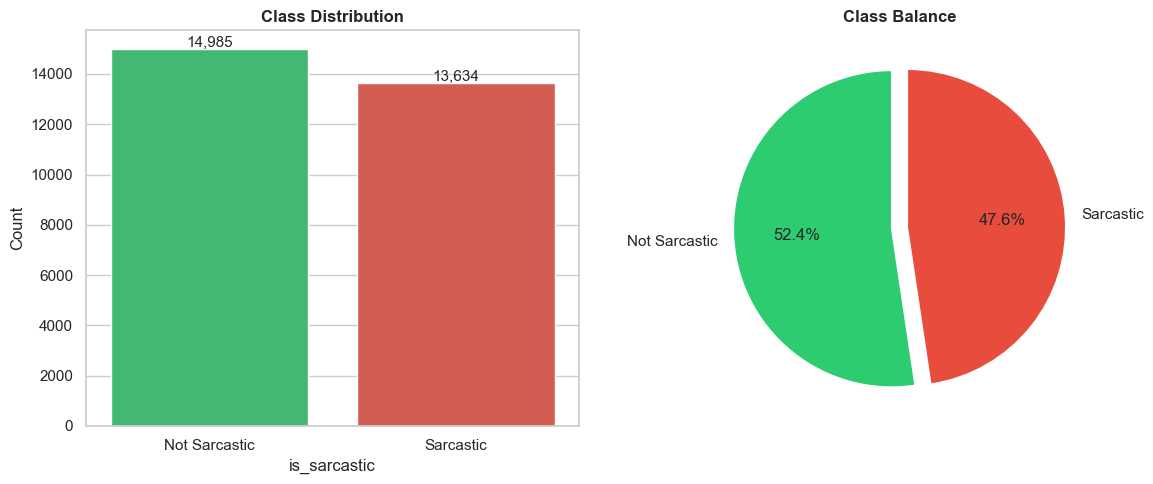

In [6]:
print('=== Class Distribution ===')
counts = df['is_sarcastic'].value_counts()
print(counts)
print(f'\nSarcastic    : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'Not Sarcastic: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.countplot(
    data=df, x='is_sarcastic',
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_xticklabels(['Not Sarcastic', 'Sarcastic'])
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 100),
                     ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Not Sarcastic', 'Sarcastic'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.05)
)
axes[1].set_title('Class Balance', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/shubhkhare/Desktop/Projects/Sarcasm Detection/outputs/01_class_distribution.png', dpi=150)
plt.show()

## 5. Headline Length Analysis

=== Word Count Statistics ===
                count   mean   std  min  25%   50%   75%    max
is_sarcastic                                                   
0             14985.0   9.82  2.89  2.0  8.0  10.0  12.0   38.0
1             13634.0  10.31  3.85  2.0  8.0  10.0  13.0  151.0


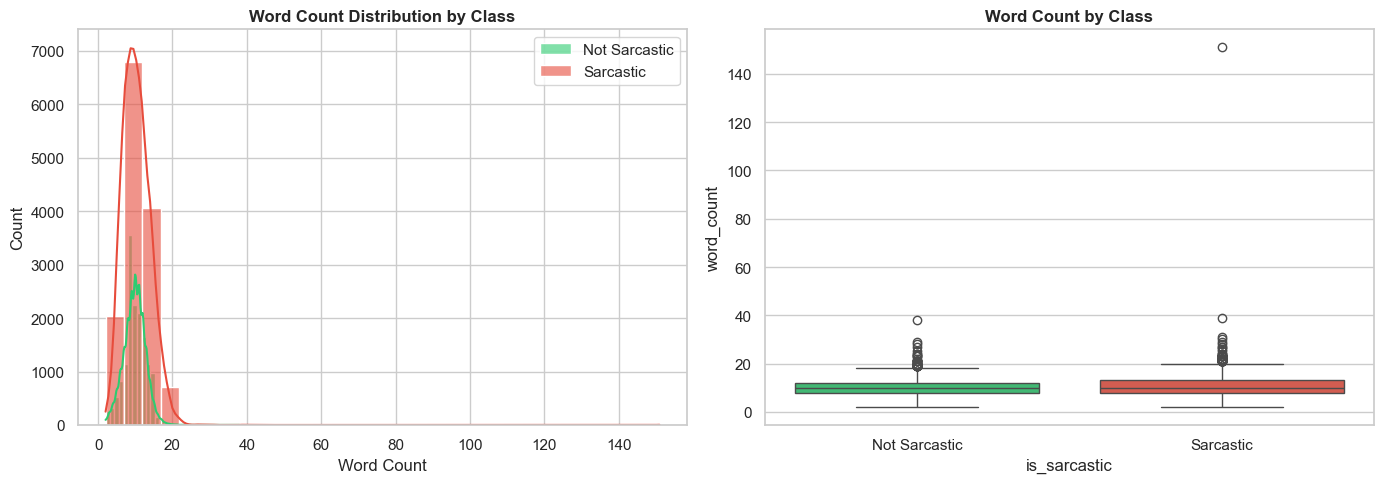


Overall avg word count : 10.0
Max word count         : 151
95th percentile        : 16


In [7]:
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

print('=== Word Count Statistics ===')
print(df.groupby('is_sarcastic')['word_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, '#2ecc71', 'Not Sarcastic'), (1, '#e74c3c', 'Sarcastic')]:
    subset = df[df['is_sarcastic'] == label]['word_count']
    sns.histplot(subset, bins=30, kde=True, ax=axes[0],
                 color=color, label=name, alpha=0.6)

axes[0].set_title('Word Count Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].legend()

sns.boxplot(
    data=df, x='is_sarcastic', y='word_count',
    palette=['#2ecc71', '#e74c3c'], ax=axes[1]
)
axes[1].set_xticklabels(['Not Sarcastic', 'Sarcastic'])
axes[1].set_title('Word Count by Class', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/shubhkhare/Desktop/Projects/Sarcasm Detection/outputs/01_word_count.png', dpi=150)
plt.show()

print(f'\nOverall avg word count : {df["word_count"].mean():.1f}')
print(f'Max word count         : {df["word_count"].max()}')
print(f'95th percentile        : {df["word_count"].quantile(0.95):.0f}')

## 6. Word Clouds

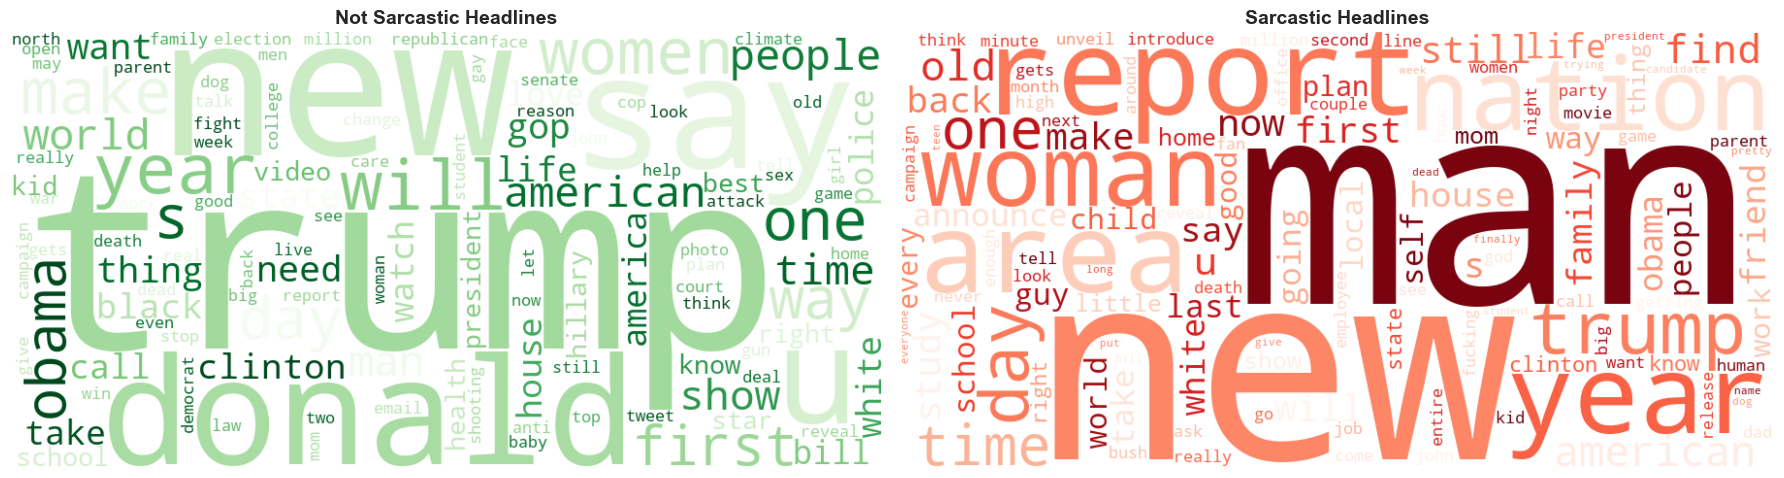

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (label, cmap, title) in enumerate([
    (0, 'Greens', 'Not Sarcastic Headlines'),
    (1, 'Reds',   'Sarcastic Headlines')
]):
    text = ' '.join(df[df['is_sarcastic'] == label]['headline'].astype(str))
    wc = WordCloud(
        width=900, height=450,
        background_color='white',
        colormap=cmap,
        max_words=120,
        collocations=False
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/Users/shubhkhare/Desktop/Projects/Sarcasm Detection/outputs/01_wordclouds.png', dpi=150)
plt.show()

## 7. Top Words per Class

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


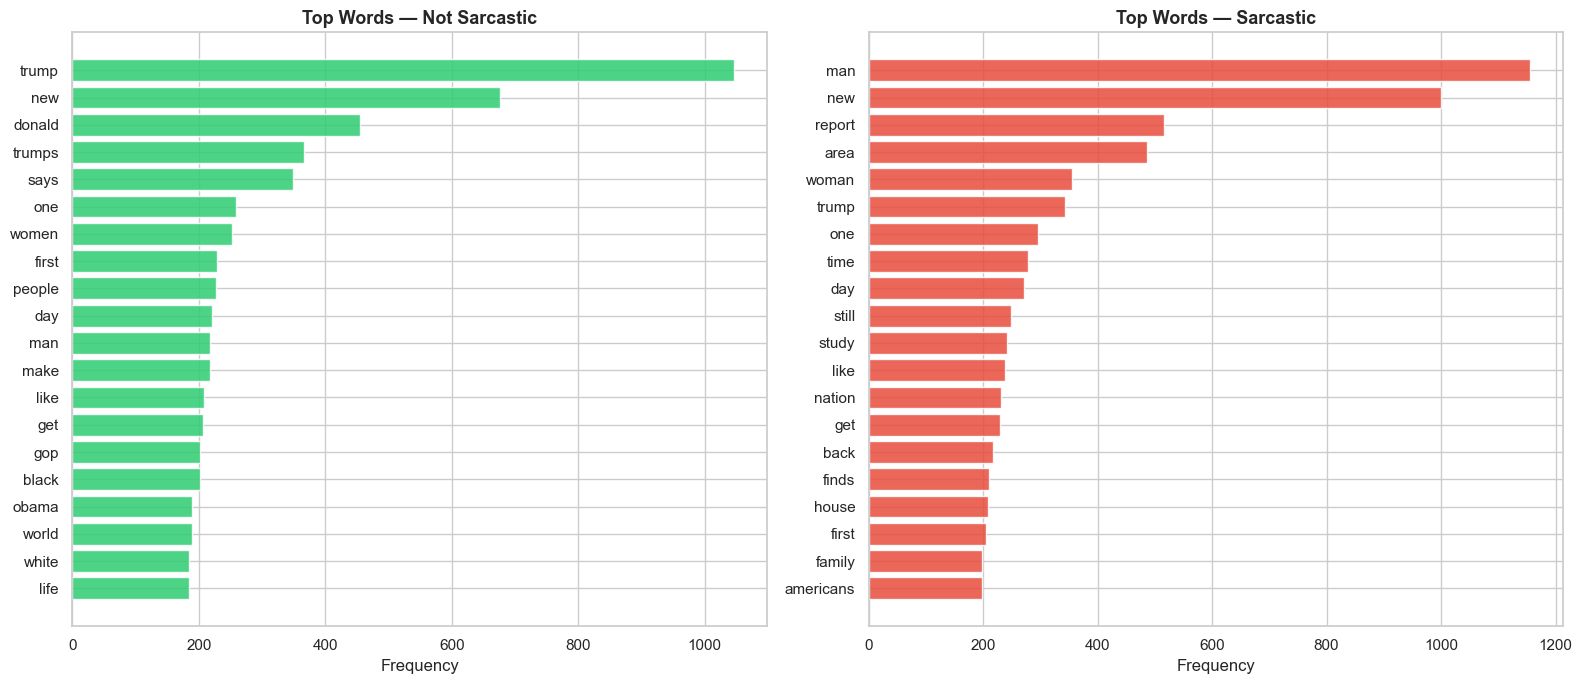

In [9]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
stop = set(stopwords.words('english'))

def top_words(texts, n=20):
    words = []
    for t in texts:
        tokens = re.sub(r'[^a-z ]', '', str(t).lower()).split()
        words.extend([w for w in tokens if w not in stop and len(w) > 2])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, (label, color, title) in enumerate([
    (0, '#2ecc71', 'Top Words — Not Sarcastic'),
    (1, '#e74c3c', 'Top Words — Sarcastic')
]):
    subset = df[df['is_sarcastic'] == label]['headline']
    words, freqs = zip(*top_words(subset))
    axes[i].barh(words[::-1], freqs[::-1], color=color, alpha=0.85)
    axes[i].set_title(title, fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('/Users/shubhkhare/Desktop/Projects/Sarcasm Detection/outputs/01_top_words.png', dpi=150)
plt.show()

## 8. Sample Headlines

In [10]:
print('=== SARCASTIC Headlines (from TheOnion) ===')
for h in df[df['is_sarcastic']==1]['headline'].sample(8, random_state=42).values:
    print(f'  • {h}')

print('\n=== NOT SARCASTIC Headlines (from HuffPost) ===')
for h in df[df['is_sarcastic']==0]['headline'].sample(8, random_state=42).values:
    print(f'  • {h}')

=== SARCASTIC Headlines (from TheOnion) ===
  • male friends depart for annual camping trip to complain about camping
  • everything reminds man of 'her'
  • longtime sexual fantasy awkwardly fulfilled
  • 'back to dock' voted most popular destination among current rowboat passengers
  • kasich trying to find other states where he is beloved multi-term governor
  • breakup doesn't seem to have changed relationship
  • parents gently explain to son why family dog had to be blown up with dynamite
  • argument about capital of australia occurs 10 feet from encyclopedia

=== NOT SARCASTIC Headlines (from HuffPost) ===
  • this artist gives renaissance-style sculptures a goofy modern twist
  • what's leaving netflix in may 2016?
  • dogs in asia: doctors not dinner
  • rand's filibuster two-fer
  • divorcing parents: 10 questions to ask before fighting over the kids
  • this is where students get suspended from school the most
  • a plea to free archbishop mar gregorios yohanna ibrahim and 

## 9. Save

In [11]:
df.to_csv('/Users/shubhkhare/Desktop/Projects/Sarcasm Detection/data/sarcasm_clean.csv', index=False)
print(f'Saved! Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Saved! Shape: (28619, 4)
Columns: ['headline', 'is_sarcastic', 'word_count', 'char_count']


---
## ✅ EDA Summary
- ~28,000 headlines, near-perfectly balanced classes
- Average headline: **9–10 words** — ideal for all 5 models
- Sarcastic headlines contain exaggerated, ironic language patterns
- No missing values, no duplicates — very clean dataset
- **Next:** Preprocessing → `02_preprocessing.ipynb`